# Gym Churn Analysis

Using gym churn data to explore different aspects of data analysis and predictive modeling.

The notebook works through the following steps:
- Exploratory data analysis - check data for missing values, plot churn rate by cat variables, plot numeric feature distributions by churn
- Statistical tests - check whether the means of numerical variables for churn vs not churn populations are statistically significant
- Predicting churn - train a random forest model to predict churn and find the important features
- Cohort analysis


## Data Columns
The dataset contains churn information for the current month and member data for the previous month.

- Churn - cancellation for the current month
- Gender - The user's gender
- Near_Location - If the user lives or works in the neighborhood where the gym is located.
- Partner - If the user works in an associated company (the gym has associated companies whose employees get discounts; in those cases, the gym stores information about the clients' employers).
- Promo_friends - If the user originally signed up through a "bring a friend" offer (they used a friend's promotional code when they paid the first subscription).
- Phone - If the user provided their phone number.
- Contract_period - The customer's contract period in months
- Group_visits - Whether the customer's membership allows to bring friends
- Age - The customer's age
- Avg_additional_charges_total
- Month_to_end_contract - Months until the contract ends
- Lifetime - the time (in months) since the user first arrived at the gym.
- Avg_class_frequency_total - Average number of classes the customer attended per week overall
- Avg_class_frequency_current_month - Average number of classes the customer attended per week in the current month

## TODO
- Clustering to find valuable segments
    - Cluster within churners or non-churners separately to see what churner vs loyal segments look like

- Statistical tests on clusters
- bootstrapping for churn prediction to create confidence intervals
- Extra data generation to balance classes and improve churn prediction performance 
- SHAP feature importance explanation

- Survival analysis
- Cohort analysis: Look at groups that joined around the same time and see how their churn patterns evolve.
    - run chi-square tests of indepencence for contingency tables

## Exploratory Data Analysis

In [142]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from minieda import summarize # pip install git+https://github.com/dbolotov/minieda.git
from scipy.stats import ttest_ind, t

import time
from pprint import pprint

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

pd.set_option("display.precision", 2)


In [3]:
df = pd.read_csv("gym_churn_us.csv")

In [4]:
df

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,1,1,1,0,1,12,0,33,2.406023,12.0,8,2.284497,2.349070,0
3996,0,1,0,0,1,1,1,29,68.883764,1.0,1,1.277168,0.292859,1
3997,1,1,1,1,1,12,0,28,78.250542,11.0,2,2.786146,2.831439,0
3998,0,1,1,1,1,6,0,32,61.912657,5.0,3,1.630108,1.596237,0


In [5]:
summarize(df)

,dtype,count,unique,unique_perc,missing,missing_perc,zero,zero_perc,mean,std,min,50%,max,skew
gender,int64,4000,2,0.05,0,0.0,1959,48.98,0.51,0.50,0.00,1.00,1.00,-0.04
Near_Location,int64,4000,2,0.05,0,0.0,619,15.48,0.85,0.36,0.00,1.00,1.00,-1.91
Partner,int64,4000,2,0.05,0,0.0,2053,51.32,0.49,0.50,0.00,0.00,1.00,0.05
Promo_friends,int64,4000,2,0.05,0,0.0,2766,69.15,0.31,0.46,0.00,0.00,1.00,0.83
Phone,int64,4000,2,0.05,0,0.0,386,9.65,0.90,0.30,0.00,1.00,1.00,-2.73
Contract_period,int64,4000,3,0.08,0,0.0,0,0.00,4.68,4.55,1.00,1.00,12.00,0.71
Group_visits,int64,4000,2,0.05,0,0.0,2351,58.78,0.41,0.49,0.00,0.00,1.00,0.36
Age,int64,4000,23,0.57,0,0.0,0,0.00,29.18,3.26,18.00,29.00,41.00,-0.06
Avg_additional_charges_total,float64,4000,4000,100.00,0,0.0,0,0.00,146.94,96.36,0.15,136.22,552.59,0.62
Month_to_end_contract,float64,4000,12,0.30,0,0.0,0,0.00,4.32,4.19,1.00,1.00,12.00,0.81


In [19]:
# Create lists of categorical and numerical variables
cat_vars = ["gender", "Near_Location", "Partner",  "Promo_friends", "Phone", "Contract_period", "Group_visits"]
num_vars = ["Age", "Avg_additional_charges_total", "Month_to_end_contract", "Lifetime", "Avg_class_frequency_total", "Avg_class_frequency_current_month"]

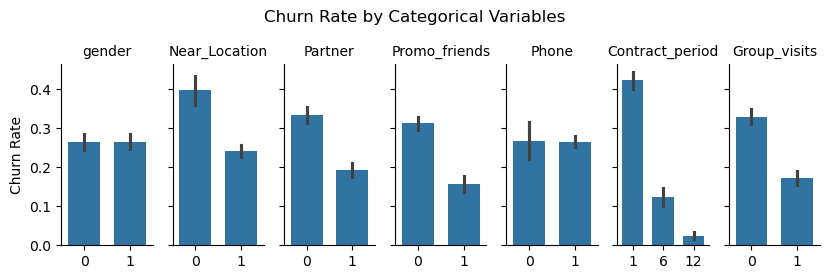

In [38]:
# Churn rate for categorical variables

g = sns.FacetGrid(
    pd.melt(df, id_vars="Churn", value_vars=cat_vars),
    col="variable", col_wrap=7, sharey=True, sharex=False, height=3, aspect=0.4)
g.map_dataframe(sns.barplot, x="value", y="Churn", estimator=lambda x: sum(x)/len(x), width=0.7)
g.set_axis_labels("", "Churn Rate")
g.set_titles("{col_name}")
g.fig.suptitle("Churn Rate by Categorical Variables")
g.fig.subplots_adjust(top=0.8)  # adjust to fit the title

plt.show()

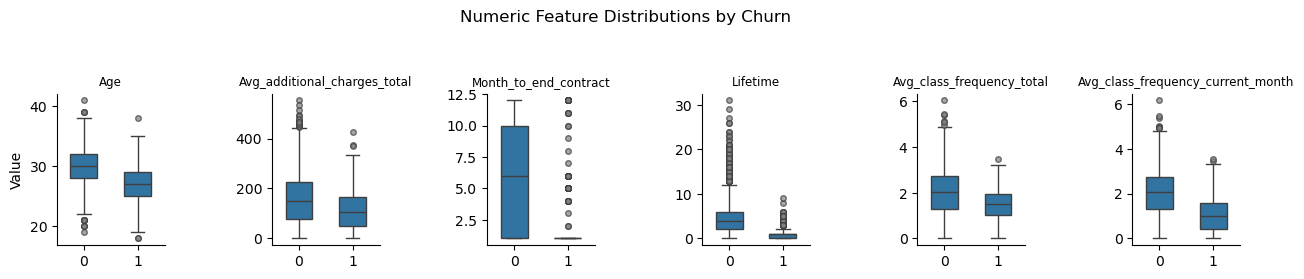

In [48]:
# Boxplots for numeric features by churn

df_plot = df.copy()

melted = pd.melt(df_plot, id_vars="Churn", value_vars=num_vars)

g = sns.FacetGrid(melted, col="variable", sharey=False, height=3, aspect=0.7)
g.map_dataframe(sns.boxplot, x="Churn", y="value", showfliers=True, 
                flierprops=dict(marker='o', markersize=4, markerfacecolor="gray", alpha=0.7),
                width=0.5)

g.set_titles("{col_name}", size=8.5)
g.set_axis_labels("", "Value")

g.fig.suptitle("Numeric Feature Distributions by Churn")
g.fig.subplots_adjust(top=0.7, wspace = 1)

plt.show()

In [17]:
# T-test 
# def run_ttest(variable):
#     churners = df[df["Churn"] == 1][variable]
#     non_churners = df[df["Churn"] == 0][variable]
#     t_stat, p_val = ttest_ind(churners, non_churners, equal_var=False)
#     print(f"{variable:<35} t-stat: {t_stat:>6.3f}   p-value: {p_val:.3e}")

def run_ttests(df, num_vars):
    results = []
    for var in num_vars:
        churners = df[df["Churn"] == 1][var]
        non_churners = df[df["Churn"] == 0][var]
        t_stat, p_val = ttest_ind(churners, non_churners, equal_var=False)
        results.append({"Variable": var, "t-stat": t_stat, "p-value": p_val})
    return(pd.DataFrame(results))

ttest_results = run_ttests(df, num_vars)
print(ttest_results)


                            Variable     t-stat        p-value
0                                Age -28.501379  1.438415e-149
1       Avg_additional_charges_total -14.391491   4.230473e-45
2              Month_to_end_contract -35.996482  1.284839e-244
3                           Lifetime -46.989716   0.000000e+00
4          Avg_class_frequency_total -19.367540   2.011288e-78
5  Avg_class_frequency_current_month -32.553372  1.049332e-193


In [51]:
import numpy as np
import pandas as pd


def run_ttests_with_means(df, num_vars, churn_col="Churn", pretty=False):
    """
    Compare numeric variables between churners (1) and non-churners (0).
    Uses Welch's t-test (unequal variances), and reports:
      - group means
      - mean difference (churners - non-churners)
      - t-statistic, p-value
      - 95% CI for the mean difference (Welch)
      - Hedges' g (effect size, small-sample corrected)

    Params
    ------
    df : DataFrame
    num_vars : list[str]
    churn_col : str (default "Churn")
    pretty : bool -> if True, returns a formatted table (strings)

    Returns
    -------
    DataFrame
    """
    rows = []

    for var in num_vars:
        g1 = df[df[churn_col] == 1][var].dropna()  # churners
        g0 = df[df[churn_col] == 0][var].dropna()  # non-churners

        n1, n0 = len(g1), len(g0)
        m1, m0 = g1.mean(), g0.mean()
        s1, s0 = g1.std(ddof=1), g0.std(ddof=1)

        # Welch t-test
        t_stat, p_val = ttest_ind(g1, g0, equal_var=False)

        # Mean difference and its SE (Welch)
        diff = m1 - m0
        se = np.sqrt((s1**2 / n1) + (s0**2 / n0))

        # Welch-Satterthwaite degrees of freedom
        df_welch_num = (s1**2 / n1 + s0**2 / n0) ** 2
        df_welch_den = ((s1**2 / n1) ** 2) / (n1 - 1) + ((s0**2 / n0) ** 2) / (n0 - 1)
        dof = df_welch_num / df_welch_den

        # 95% CI for mean difference
        t_crit = t.ppf(0.975, dof)
        ci_low = diff - t_crit * se
        ci_high = diff + t_crit * se

        # Effect size: Hedges' g (using pooled SD, then small-sample correction)
        sp2 = ((n1 - 1) * s1**2 + (n0 - 1) * s0**2) / (n1 + n0 - 2)
        sp = np.sqrt(sp2)
        d = diff / sp if sp > 0 else np.nan
        J = 1 - (3 / (4*(n1 + n0) - 9))  # small sample correction
        g_hedges = d * J

        rows.append({
            "Variable": var,
            "n_churn": n1, "mean_churn": m1,
            "n_non": n0, "mean_non": m0,
            "diff_mean": diff,
            "t_stat": t_stat, "p_value": p_val,
            "ci_low": ci_low, "ci_high": ci_high,
            "hedges_g": g_hedges
        })

    out = pd.DataFrame(rows).sort_values("p_value")

    if not pretty:
        return out.reset_index(drop=True)

    # Formatting
    out_fmt = out.copy()
    out_fmt["mean_churn"] = out_fmt["mean_churn"].map(lambda x: f"{x:.3f}")
    out_fmt["mean_non"]   = out_fmt["mean_non"].map(lambda x: f"{x:.3f}")
    out_fmt["diff_mean"]  = out_fmt["diff_mean"].map(lambda x: f"{x:+.3f}")
    out_fmt["t_stat"]     = out_fmt["t_stat"].map(lambda x: f"{x:.3f}")
    out_fmt["p_value"]    = out_fmt["p_value"].map(lambda x: f"{x:.3e}")
    out_fmt["ci"]         = out.apply(lambda r: f"[{r.ci_low:.3f}, {r.ci_high:.3f}]", axis=1)
    out_fmt["hedges_g"]   = out_fmt["hedges_g"].map(lambda x: f"{x:+.3f}")

    cols = ["Variable", "mean_churn", "mean_non",
            "diff_mean", "t_stat", "p_value", "ci", "hedges_g"]
    return out_fmt[cols].reset_index(drop=True)

results = run_ttests_with_means(df, num_vars, pretty=True)
results

,Variable,mean_churn,mean_non,diff_mean,t_stat,p_value,ci,hedges_g
0,Lifetime,0.991,4.712,-3.721,-46.990,0.000e+00,"[-3.876, -3.566]",-1.104
1,Month_to_end_contract,1.663,5.283,-3.621,-35.996,1.285e-244,"[-3.818, -3.423]",-0.934
2,Avg_class_frequency_current_month,1.045,2.028,-0.983,-32.553,1.049e-193,"[-1.043, -0.924]",-1.025
3,Age,26.990,29.977,-2.987,-28.501,1.438e-149,"[-3.192, -2.781]",-1.002
4,Avg_class_frequency_total,1.475,2.025,-0.550,-19.368,2.011e-78,"[-0.606, -0.494]",-0.584
5,Avg_additional_charges_total,115.083,158.446,-43.363,-14.391,4.230e-45,"[-49.271, -37.454]",-0.459


## Predicting Churn

Training a Random Forest model whether a customer churns in the current month given data for the past month.

In [52]:
print(df['Churn'].value_counts(normalize=True))

Churn
0    0.73475
1    0.26525
Name: proportion, dtype: float64


In [54]:
# Split the data
X = df[cat_vars + num_vars]
y = df['Churn']

# Split into training and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Define preprocessing for numeric and categorical features
numeric_preprocessing = Pipeline([
    ('scale', StandardScaler())
])

categorical_preprocessing = Pipeline([
    ('encode', OneHotEncoder(drop='first', sparse_output=False))  # one-hot; drop first feature to avoid multicollinearity
])

# Combine into a column transformer
preprocessor = ColumnTransformer([
    ('num', numeric_preprocessing, num_vars),
    ('cat', categorical_preprocessing, cat_vars)
])

In [55]:
# Grid search

# Base pipeline
clf_pipeline = Pipeline([
    ('pre', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

# Define hyperparameter grid
param_grid = {
    'model__n_estimators': [40,100,200],
    'model__max_depth': [None],
    'model__min_samples_leaf': [1, 3, 5, 7],
    'model__max_features': ['sqrt']
}

# Grid search with cross-validation
grid_search = GridSearchCV(
    estimator=clf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

# Fit grid search on training data
print("\n----- GRID SEARCH -----\n")
start_time = time.time()
grid_search.fit(X_train, y_train)
print(f"\nGrid search completed in {time.time() - start_time:.2f} seconds")

print("\n----- Best Grid Search Result -----")
print(f"Accuracy: {grid_search.best_score_:.4f} ± {grid_search.cv_results_['std_test_score'][grid_search.best_index_]:.4f}")
print("Parameters:")
pprint(grid_search.best_params_)


----- GRID SEARCH -----

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Grid search completed in 8.20 seconds

----- Best Grid Search Result -----
Accuracy: 0.9206 ± 0.0085
Parameters:
{'model__max_depth': None,
 'model__max_features': 'sqrt',
 'model__min_samples_leaf': 1,
 'model__n_estimators': 100}


In [56]:
# Use best model from grid search
clf_pipeline = grid_search.best_estimator_

# Evaluate
print(f"Train accuracy: {clf_pipeline.score(X_train, y_train):.4f}")
print(f"Test accuracy:  {clf_pipeline.score(X_test, y_test):.4f}")

y_test_pred = clf_pipeline.predict(X_test)
print("\n----- Classification Report -----\n")
print(classification_report(y_test, y_test_pred))
print("\n----- Confusion Matrix -----\n")
cm = confusion_matrix(y_test, y_test_pred, labels=clf_pipeline.classes_)
print(cm)

# Print normalized feature importances
model = clf_pipeline.named_steps['model']
encoded_feature_names = clf_pipeline.named_steps['pre'].get_feature_names_out()

feat_importance_df = pd.DataFrame({
    'feature': encoded_feature_names,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\n----- Feature Importance -----\n")
print(feat_importance_df)

Train accuracy: 1.0000
Test accuracy:  0.9263

----- Classification Report -----

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       588
           1       0.89      0.82      0.86       212

    accuracy                           0.93       800
   macro avg       0.91      0.89      0.90       800
weighted avg       0.93      0.93      0.93       800


----- Confusion Matrix -----

[[567  21]
 [ 38 174]]

----- Feature Importance -----

                                   feature  importance
3                            num__Lifetime    0.258619
5   num__Avg_class_frequency_current_month    0.174873
4           num__Avg_class_frequency_total    0.141100
0                                 num__Age    0.137044
1        num__Avg_additional_charges_total    0.088043
2               num__Month_to_end_contract    0.083394
12                 cat__Contract_period_12    0.035125
13                     cat__Group_visits_1    0.017870
11       

## Cohort analysis

Find groups of people that started around the same time and see how their churn patterns evolve.

Bin customers into 4 cohorts - New (<3 months), Early (3-5 months), Established (6-11 months), Loyal (12+ months).

In [57]:
df

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,1,1,1,0,1,12,0,33,2.406023,12.0,8,2.284497,2.349070,0
3996,0,1,0,0,1,1,1,29,68.883764,1.0,1,1.277168,0.292859,1
3997,1,1,1,1,1,12,0,28,78.250542,11.0,2,2.786146,2.831439,0
3998,0,1,1,1,1,6,0,32,61.912657,5.0,3,1.630108,1.596237,0


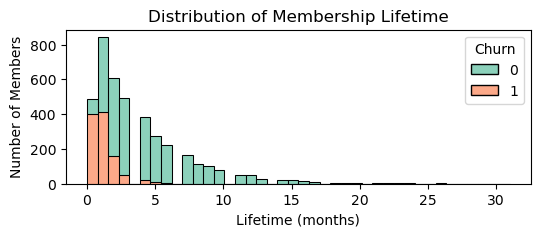

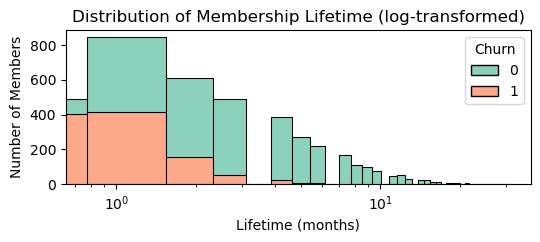

In [82]:
plt.figure(figsize=(6,2))

sns.histplot(data=df, x="Lifetime", bins=40, kde=False, hue="Churn", multiple="stack", palette="Set2")

plt.title("Distribution of Membership Lifetime")
plt.xlabel("Lifetime (months)")
plt.ylabel("Number of Members")
plt.show()

plt.figure(figsize=(6,2))
sns.histplot(data=df, x="Lifetime", bins=40, kde=False, hue="Churn", multiple="stack", palette="Set2")
plt.xscale("log")
plt.title("Distribution of Membership Lifetime (log-transformed)")
plt.xlabel("Lifetime (months)")
plt.ylabel("Number of Members")
plt.show()

In [97]:
# Separate data into cohorts based on Lifetime:

df_cohort = df.copy(deep=True)

df_cohort["Cohort"] = pd.cut(x=df_cohort["Lifetime"], bins=[0, 3, 6, 12, np.inf], right=False,
                             labels=["New", "Early", "Established", "Loyal"], retbins=False,
                             precision=3, include_lowest=True, duplicates='raise', ordered=True)

In [98]:
df_cohort

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn,Cohort
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0,Early
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0,Established
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0,New
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0,New
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0,Early
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,1,1,1,0,1,12,0,33,2.406023,12.0,8,2.284497,2.349070,0,Established
3996,0,1,0,0,1,1,1,29,68.883764,1.0,1,1.277168,0.292859,1,New
3997,1,1,1,1,1,12,0,28,78.250542,11.0,2,2.786146,2.831439,0,New
3998,0,1,1,1,1,6,0,32,61.912657,5.0,3,1.630108,1.596237,0,Early


In [145]:
# Create summary with member counts, percentages, and churn percentages by cohort
df_c_summary = (df_cohort.groupby("Cohort", observed=False)
                .agg(Member_Count=("Churn", "size"),
                     Member_Perc=("Churn", lambda x: len(x) / len(df_cohort)),
                     Churn_Perc=("Churn", "mean"),
                     Age_mean=("Age", "mean"),
                     Avg_addl_charges_tot_mean =("Avg_additional_charges_total", "mean"),
                     Avg_class_f_tot_mean=("Avg_class_frequency_total", "mean"),
                     Avg_class_f_cm_mean=("Avg_class_frequency_current_month", "mean")))

df_c_summary["Member_Perc"] = (df_c_summary["Member_Perc"] * 100)
df_c_summary["Churn_Perc"]  = (df_c_summary["Churn_Perc"] * 100)

df_c_summary


# num_vars = ["Age", "Avg_additional_charges_total", "Month_to_end_contract", "Lifetime", "Avg_class_frequency_total", "Avg_class_frequency_current_month"]
#

,Member_Count,Member_Perc,Churn_Perc,Age_mean,Avg_addl_charges_tot_mean,Avg_class_f_tot_mean,Avg_class_f_cm_mean
Cohort,,,,,,,
New,1940,48.50,50.21,28.47,137.53,1.73,1.52
Early,1146,28.65,7.07,29.79,156.29,2.01,1.98
Established,722,18.05,0.83,30.00,153.78,2.03,2.02
Loyal,192,4.80,0.00,29.68,160.56,2.01,2.02


Average class frequency total - Churners tend to leave early, and those who stay quickly settle into a routine of about 2 visits per week. Past 6 months, engagement stabilizes, suggesting that keeping members engaged through the first 3 months is critical.

TODO
- Is there a significant difference in mean ages, and in avg class frequency?


In [133]:
pd.crosstab(df_cohort["Cohort"], df_cohort["Contract_period"], normalize="index") #normalized so each cohort (row) sums to 1.

Contract_period,1,6,12
Cohort,,,
New,0.652577,0.180412,0.167010
Early,0.462478,0.242583,0.294939
Established,0.441828,0.225762,0.332410
Loyal,0.479167,0.218750,0.302083


The above table shows that among new members, 65% are on a 1-month contract. Surprisingly, among Loyal members (12+ months attendance), almost half (48%) are on 1-month contract. If monthly cost difference between 1- and 12-month contracts is small, members might not bother to switch. A potential action here is to target loyal month-to-month members with offers to switch to a discounted 12-month plan. Even if churn is already low, locking them in creates more predictable revenue.

In [ ]:
df_cohort.groupby("Cohort", observed=False).